In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("tiktok_analytics.csv")

In [3]:
df.head(10)

,Video_ID,Video_Duration_Sec,Uses_Trending_Sound,Upload_Hour,Views,Likes,Comments,Shares
0,TK-8000,132,Yes,9,2456,124.0,7,9
1,TK-8001,106,No,8,1116,56.0,3,4
2,TK-8002,161,NaN,8,659,33.0,1,2
3,TK-8003,54,No,23,4671,236.0,13,17
4,TK-8004,30,NaN,22,35123,1780.0,102,130
5,TK-8005,128,Yes,4,3747,189.0,10,13
6,TK-8006,136,No,0,2597,131.0,7,9
7,TK-8007,88,Yes,1,4418,224.0,12,16
8,TK-8008,122,No,22,2855,144.0,8,10
9,TK-8009,127,No,13,329,16.0,0,1


In [5]:
df.set_index("Video_ID", inplace= True)

In [6]:
df.head(5)

,Video_Duration_Sec,Uses_Trending_Sound,Upload_Hour,Views,Likes,Comments,Shares
Video_ID,,,,,,,
TK-8000,132,Yes,9,2456,124.0,7,9
TK-8001,106,No,8,1116,56.0,3,4
TK-8002,161,NaN,8,659,33.0,1,2
TK-8003,54,No,23,4671,236.0,13,17
TK-8004,30,NaN,22,35123,1780.0,102,130


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, TK-8000 to TK-8499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Video_Duration_Sec   500 non-null    int64  
 1   Uses_Trending_Sound  475 non-null    object 
 2   Upload_Hour          500 non-null    int64  
 3   Views                500 non-null    int64  
 4   Likes                490 non-null    float64
 5   Comments             500 non-null    int64  
 6   Shares               500 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 47.4+ KB


In [8]:
df.shape

(500, 7)

In [9]:
df['Likes'] = df['Likes'].fillna(df['Likes'].median())

In [10]:
df['Total_Interactions']= df['Likes'] + df['Comments']+ df['Shares']

In [11]:
df['Engagement_Rate']= (df['Total_Interactions'] / df['Views']) * 100

In [12]:
Top_videos = df.sort_values(by= 'Engagement_Rate' , ascending= False)

In [14]:
print(Top_videos[['Views', 'Total_Interactions', 'Engagement_Rate']].head())

          Views  Total_Interactions  Engagement_Rate
Video_ID                                            
TK-8046     912               165.5        18.146930
TK-8483    1816               171.5         9.443833
TK-8138    1893               171.5         9.059694
TK-8129    2078               173.5         8.349374
TK-8429    2233               174.5         7.814599


In [16]:
hourly_views= df.groupby('Upload_Hour')['Views'].mean()

In [17]:
plt.figure(figsize=(12,6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

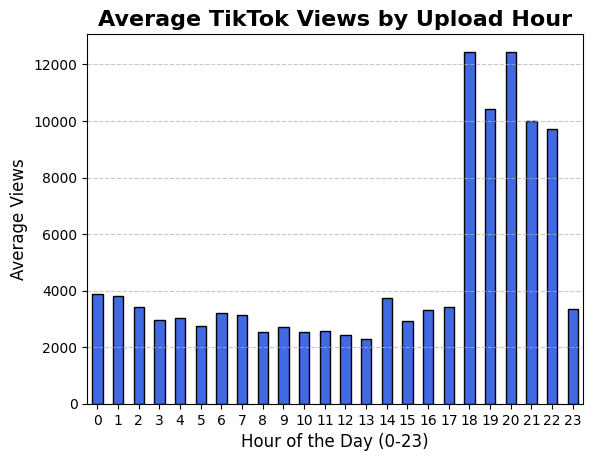

In [21]:

hourly_views.plot(kind='bar', color='royalblue', edgecolor='black' )
plt.title('Average TikTok Views by Upload Hour', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [22]:
df_clean= df.dropna(subset= ['Uses_Trending_Sound'])

In [24]:
sound_views= df_clean.groupby('Uses_Trending_Sound')['Views'].mean()

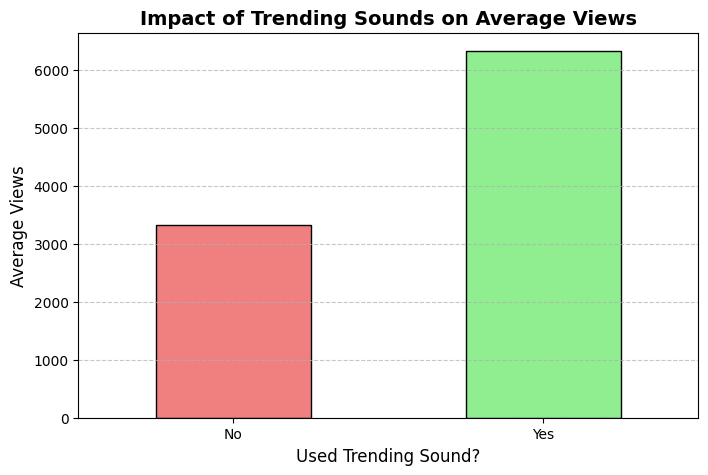

In [28]:
plt.figure(figsize=(8,5))
sound_views.plot(kind='bar', color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Impact of Trending Sounds on Average Views', fontsize=14, fontweight='bold')
plt.xlabel('Used Trending Sound?', fontsize=12)
plt.ylabel('Average Views', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
